<div style="width: 100%; clear: both;">
<div style="float: left; width: 50%;">
<img src="http://www.uoc.edu/portal/_resources/common/imatges/marca_UOC/UOC_Masterbrand.jpg", align="left">
</div>
<div style="float: right; width: 50%;">
<p style="margin: 0; padding-top: 22px; text-align:right;">M2.875 · Deep Learning · PEC2</p>
<p style="margin: 0; text-align:right;">2025-2 · Máster universitario en Ciencia de datos (Data science)</p>
<p style="margin: 0; text-align:right; padding-button: 100px;">Estudios de Informática, Multimedia y Telecomunicación</p>
</div>
</div>
<div style="width:100%;">&nbsp;</div>


# PEC 2: Redes neuronales recurrentes con Keras


<u>Consideraciones generales</u>:

- Esta PEC debe realizarse de forma **estrictamente individual**. Cualquier indicio de copia será penalizado con un suspenso (D) para todas las partes implicadas y la posible evaluación negativa de la asignatura de forma íntegra.
- Es necesario que el estudiante indique **todas las fuentes** que ha utilizado para la realización de la PEC. De no ser así, se considerará que el estudiante ha cometido plagio, siendo penalizado con un suspenso (D) y la posible evaluación negativa de la asignatura de forma íntegra.

<u>Formato de la entrega</u>:

- Algunos ejercicios pueden suponer varios minutos de ejecución, por lo que la entrega debe hacerse en **formato notebook** y en **formato html**, donde se vea el código, los resultados y comentarios de cada ejercicio. Se puede exportar el notebook a HTML desde el menú File $\to$ Download as $\to$ HTML.
- Existe un tipo de celda especial para albergar texto. Este tipo de celda os será muy útil para responder a las diferentes preguntas teóricas planteadas a lo largo de la actividad. Para cambiar el tipo de celda a este tipo, en el menú: Cell $\to$ Cell Type $\to$ Markdown.

<div class="alert alert-block alert-info">
<strong>Nombre y apellidos: JULIO ÚBEDA QUESADA</strong>
</div>

# 0. Contexto y carga de librerías

En esta práctica exploraremos el uso de **Redes Neuronales Recurrentes (RNN)** y sus variantes modernas (LSTM, GRU) aplicadas a diferentes problemas de series temporales y procesamiento de legunaje natural. Las RNN son especialmente útiles cuando los datos presentan una **estructura secuencial**, ya que permiten capturar dependencias a lo largo del tiempo o del texto.

En los ejercicios se trabajarán desde ejemplos sintéticos hasta aplicaciones reales en finanzas, análisis de sentiemientos y predicción meteorológica, con el objetivo de comprender tanto el uso práctico de estas arquitecturas como sus limitaciones.

A continuación se incluyen las librerías necesarias para realizar esta PEC:

In [21]:
# Proporciona funciones para interactuar con el sistema operativo (como rutas de archivos)
import os  

# Permite modificar aspectos del entorno de ejecución de Python, como la lista de rutas de búsqueda de módulos (sys.path)
import sys 

# Sube un nivel desde /PEC/
root_dir = os.path.abspath('..')  
sys.path.append(root_dir)

# Análisis y manipulación de datos
import pandas as pd
pd.set_option('display.float_format', '{:.2f}'.format)
pd.set_option('display.max_columns', None)

# Visualización de datos
import matplotlib.pyplot as plt
import seaborn as sns

# Operaciones matematicas y vectorizacion
import numpy as np
import random

# Librerias para DL
from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import root_mean_squared_error, mean_absolute_error
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay, classification_report


import tensorflow as tf
from tensorflow import keras
import tensorflow_datasets as tfds
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import SimpleRNN, Dense, Input, GRU, LSTM, Dropout, Embedding, Attention, GlobalAveragePooling1D
from tensorflow.keras.callbacks import EarlyStopping
from tensorflow.keras.preprocessing.sequence import pad_sequences
from tensorflow.keras import regularizers
from tensorflow.keras.models import Model

import torch
import torch.nn as nn
from torch.utils.data import DataLoader, TensorDataset

ModuleNotFoundError: No module named 'seaborn'

# 1. RNN básica

En este ejercicio vamos a explorar cómo una **Red Neuronal Recurrente (RNN)** puede aprender patrones en datos de series temporales. Las RNN son un tipo de red diseñado para manejar secuencias, ya que no procesan los datos como entradas independientes, sino que mantienen un estado interno que les permite recordar información sobre pasos previos. Esto las hace especialmente útiles en tareas como predicción de series temporales, procesamiento de lenguaje natural (NLP) o análisis de señales.

Trabajaremos con una serie temporal para la predicción de la temperatura del aceite de transformadores eléctricos. Más información sobre el dataset: https://github.com/zhouhaoyi/ETDataset

En el modelado de series temporales, el parámetro `window_size` es fundamental. Representa el **número de pasos anteriores** que el modelo utilizará como entrada para predecir el siguiente valor. Podemos imaginarlo como una **ventana deslizante** (o sliding window) que se mueve a lo largo de la serie. En cada posición, recoge un bloque de datos pasados y lo utiliza para estimar el valor futuro inmediato. Por ejemplo, si `window_size = 5`, y tenemos la serie `1, 2, 3, 4, 5, 6, 7`, la red recibiría como entrada `[1, 2, 3, 4, 5]` y debería predecir como salida `6`.


Por otra parte, la **reproducibilidad** es la capacidad de obtener los **mismos resultados** cuando un experimento se repite bajo las mismas condiciones: mismo código, mismos datos de entrada, mismos hiperparámetros, mismo entorno de ejecución. En deep learning, lograr la reproducibilidad es más difícil por varias razones:
- Inicialización aleatoria de pesos de la red.
- Barajado aleatorio (shuffling) de los datos durante el entrenamiento.
- Aritmética de coma flotante. Las sumas de coma flotante no tienen porque seguir la propiedad asociativa debido al redondeo. Además, en las GPUs el orden de las operaciones puede cambiar entre ejecuciones.

Para solucionar esto, se fijan semillas aleatorias (**random seeds**) en todos los componentes que generan números aleatorios:
```python
np.random.seed()
random.seed()
tf.random.set_seed() (para TensorFlow)
```

<div style="background-color: #EDF7FF; border-color: #7C9DBF; border-left: 5px solid #7C9DBF; padding: 0.5em;">

**Ejercicio [2.5 pts.].** Carga los datos con la serie temporal, entrena una RNN simple con distintos tamaños de ventana, compara los resultados y visualizalos. Para ello:
- Descarga el dataset con una muestra reducida de los datos https://github.com/zhouhaoyi/ETDataset/blob/main/ETT-small/ETTh1.csv
- Realiza un breve análisis exploratorio de los datos.
- Preprocesa los datos de entrada.  
    - Crea una función para convertir los datos en secuencias supervisadas. Dado un tamaño de ventana (`window_size`) ha de dividir la serie en secuencias de entrada (una subventana de longitud `window_size`) y valores de salida (el valor siguiente a cada ventana).
    - Divide los datos en 70% para entrenamiento, 15% para validación y 15% para test.
    - Escala los valores entre 0 y 1.     
- Crea un modelo secuencial con:
    - Una capa `SimpleRNN` y una capa de salida `Dense`.
    - Compila el modelo con loss `mean_squared_error` y optimizador `Adam`.
    - Usa semillas aleatorias para mantener la reproducibilidad.
- Calcula el RMSE (Root Mean Squared Error) y MAE (Mean Squared Error) para los tres subconjuntos de datos. Guarda los resultados en una tabla para hacer comparaciones posteriores.
- Visualiza las curvas de loss por epoch y los valores reales vs. valores predichos. Recuerda desescalar las variables para ver los valores reales y no los normalizados.

Responde a las siguientes preguntas:
- ¿Por qué deben convertirse los datos de series temporales en ventanas deslizantes?
- ¿Qué limitaciones tiene una SimpleRNN para datos con secuencias temporales largas?
</div>


In [20]:
# Reproducibilidad 
SEED = 42
np.random.seed(SEED)
random.seed(SEED)
tf.random.set_seed(SEED)

## 1.1. Electricity Transformer Dataset (ETDataset)

El dataset ETT-small (*Electricity Transformer Temperature*) se enmarca en el problema de la distribución eléctrica, donde uno de los mayores retos es predecir la demanda futura de energía. Esta demanda es altamente variable y depende de múltiples factores como el día de la semana, estaciones del año, condiciones climáticas o eventos puntuales. La falta de modelos precisos de predicción a largo plazo obliga a los gestores a sobredimensionar la capacidad, lo que provoca ineficiencias operativas, desperdicio energético y desgaste innecesario del equipamiento.

En este contexto, la variable **temperatura del aceite del transformador (OT, *Oil Temperature*)** juega un papel clave, ya que actúa como un indicador directo del estado y la carga del transformador. Un incremento excesivo en la temperatura puede señalar condiciones de sobrecarga o riesgo operativo, mientras que valores estables indican un funcionamiento dentro de rangos seguros. Por tanto, modelar y predecir esta variable permite:

* Optimizar la gestión de la carga eléctrica.
* Prevenir fallos en transformadores.
* Reducir costes operativos y mantenimiento.
* Evitar sobreestimaciones en la planificación energética.

## 1.2. Descripción del dataset

El conjunto ETT-small contiene datos reales recogidos durante 2 años en dos regiones de una provincia de China, generando dos variantes: ETT-small-m1 y ETT-small-m2. Cada observación se registra a intervalos temporales regulares (cada 15 minutos (70,080 observaciones por serie).

Cada registro incluye 8 variables:

| Variable | Descripción                             |
| -------- | --------------------------------------- |
| `date`   | Marca temporal                          |
| `HUFL`   | High Useful Load                        |
| `HULL`   | High Useless Load                       |
| `MUFL`   | Middle Useful Load                      |
| `MULL`   | Middle Useless Load                     |
| `LUFL`   | Low Useful Load                         |
| `LULL`   | Low Useless Load                        |
| `OT`     | **Oil Temperature (variable objetivo)** |


In [17]:
# Ruta del dataset
ruta_csv = r'C:\Users\jubeda2\Documents\GitHub\Deep-learning\Módulo 3 - Redes neuronales recurrentes (RNN)\Datos\ETTh1.csv'

# Cargar el dataset
data = pd.read_csv(ruta_csv, sep=',', decimal='.', parse_dates=['date'], index_col='date')

# Primera vista de la distribucion y calidad de los datos
print("Exploración inicial del dataset:")
print(f"\nDimensiones del DataFrame: {data.shape[0]} filas, {data.shape[1]} columnas.")
print(f"\nCobertura temporal: {data.index.min()} a {data.index.max()}")
print(f"\nPrimeras filas del DataFrame:\n{data.head()}")
print(f"\nEstadísticas descriptivas:\n{data.describe()}")
print(f"\nValores nulos por columna:\n{data.isnull().sum()}")

Exploración inicial del dataset:

Dimensiones del DataFrame: 17420 filas, 7 columnas.

Cobertura temporal: 2016-07-01 00:00:00 a 2018-06-26 19:00:00

Primeras filas del DataFrame:
                      HUFL   HULL   MUFL   MULL   LUFL   LULL         OT
date                                                                    
2016-07-01 00:00:00  5.827  2.009  1.599  0.462  4.203  1.340  30.531000
2016-07-01 01:00:00  5.693  2.076  1.492  0.426  4.142  1.371  27.787001
2016-07-01 02:00:00  5.157  1.741  1.279  0.355  3.777  1.218  27.787001
2016-07-01 03:00:00  5.090  1.942  1.279  0.391  3.807  1.279  25.044001
2016-07-01 04:00:00  5.358  1.942  1.492  0.462  3.868  1.279  21.948000

Estadísticas descriptivas:
               HUFL          HULL          MUFL          MULL          LUFL  \
count  17420.000000  17420.000000  17420.000000  17420.000000  17420.000000   
mean       7.375141      2.242242      4.300239      0.881568      3.066062   
std        7.067744      2.042342      6.826

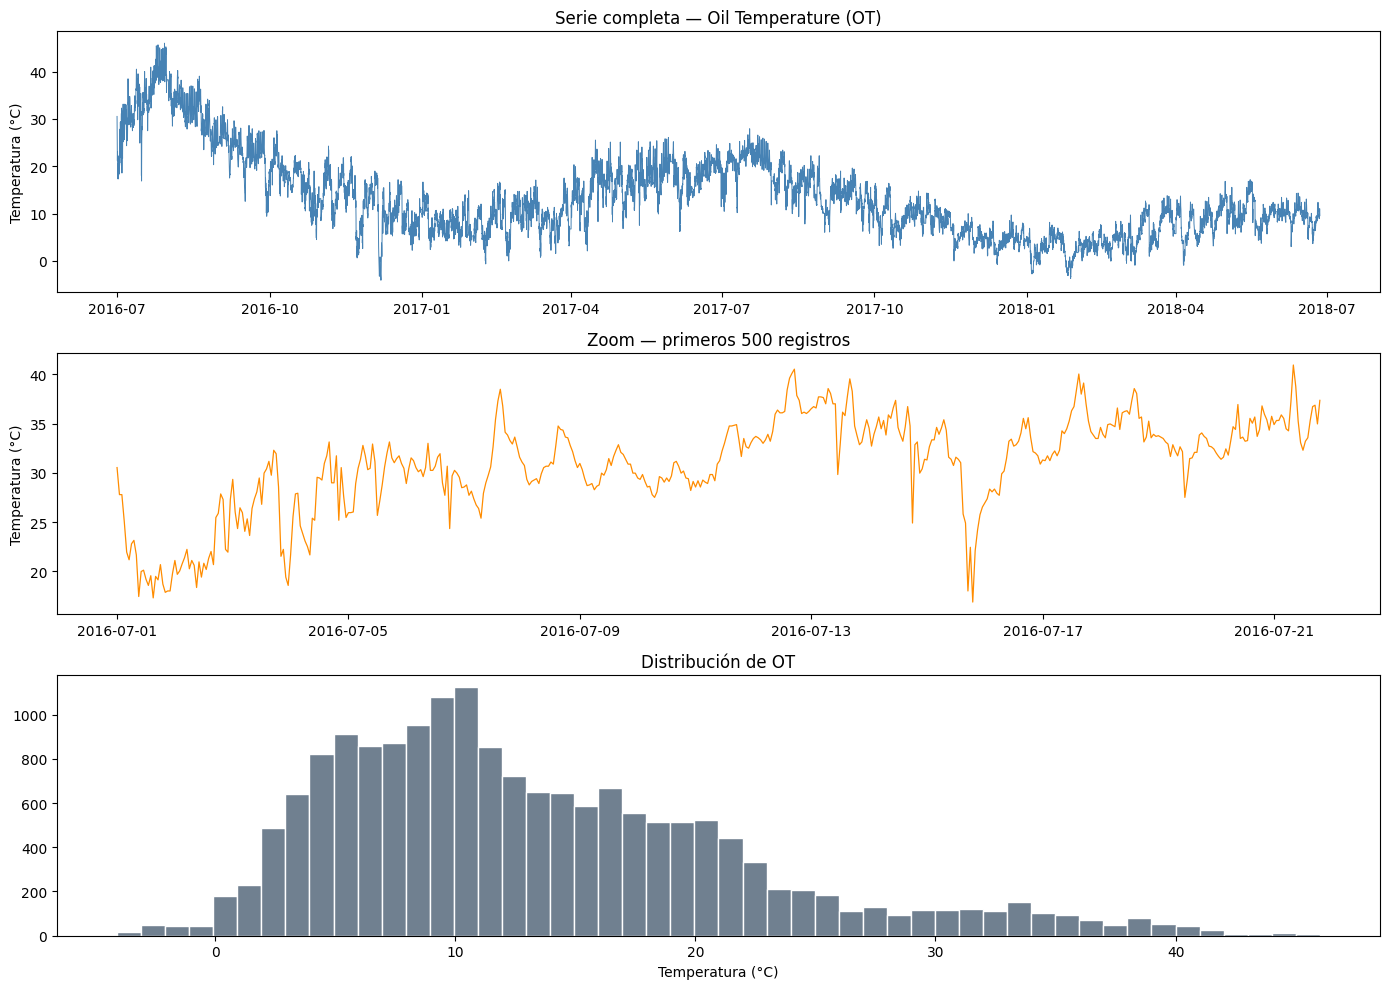

In [18]:
# Variable objetivo: temperatura del aceite del transformador (OT = Oil Temperature)
target_col = "OT"

fig, axes = plt.subplots(3, 1, figsize=(14, 10))

# Serie completa
axes[0].plot(data[target_col], color="steelblue", linewidth=0.7)
axes[0].set_title("Serie completa — Oil Temperature (OT)")
axes[0].set_ylabel("Temperatura (°C)")

# Zoom en los primeros 500 puntos (≈ 20 días horarios)
axes[1].plot(data[target_col].iloc[:500], color="darkorange", linewidth=0.9)
axes[1].set_title("Zoom — primeros 500 registros")
axes[1].set_ylabel("Temperatura (°C)")

# Distribución
axes[2].hist(data[target_col], bins=50, color="slategray", edgecolor="white")
axes[2].set_title("Distribución de OT")
axes[2].set_xlabel("Temperatura (°C)")

plt.tight_layout()
plt.show()

### 1.3. Análisis exploratorio inicial del dataset **ETT-small (ETTh1)**

#### A. Estructura general del dataset

El conjunto de datos presenta las siguientes características:

* **Dimensiones**: 17,420 observaciones y 7 variables numéricas.
* **Frecuencia**: horaria.
* **Cobertura temporal**: desde **julio de 2016 hasta junio de 2018**.

#### B. Calidad de los datos

Existe una **ausencia total de valores nulos** en todas las variables, confirmando que el dataset ha pasado un pre-procesado de datos.

#### C. Estadística descriptiva

Las variables presentan:

* **Alta variabilidad** (especialmente `HUFL` y `MUFL`).
* Distribuciones con rangos amplios.
* Diferencias significativas entre percentiles (25%, 50%, 75%).

Esto sugiere:

* Presencia de **comportamientos no estacionarios**.
* Posibles cambios de régimen en la carga eléctrica..

### D. Variable objetivo: Oil Temperature (OT)

La variable **OT (*Oil Temperature*)**:

* Se comporta como una señal continua y estable.
* No presenta valores faltantes.
* Está directamente influenciada por las variables de carga.

Desde el punto de vista del análisis:

* Es el **target principal**
* Tiene una fuerte dependencia temporal (autocorrelación)
* Es sensible a patrones de carga eléctrica

---

### 🔄 Relaciones potenciales

El dataset está diseñado para capturar la relación entre:

* **Carga eléctrica (HUFL, MUFL, LUFL, etc.)**
* **Temperatura del transformador (OT)**

Esto permite plantear hipótesis como:

* A mayor carga útil → mayor temperatura del aceite
* Diferentes tipos de carga (alta, media, baja) impactan de forma distinta
* Existen **lags temporales** entre carga y temperatura

---

### 🧠 Implicaciones para el modelado

Este análisis inicial sugiere que el dataset es especialmente adecuado para:

* Modelos de **series temporales** (ARIMA, Prophet, etc.)
* Modelos de **deep learning secuencial** como:

  * RNN
  * LSTM
  * GRU

Además, la combinación de:

* Estacionalidad
* Tendencia
* Variables exógenas

lo convierte en un caso típico de **forecasting multivariante realista**.

---

### ⚠️ Próximos pasos recomendados en el EDA

Para profundizar en el análisis exploratorio, sería recomendable:

* Analizar **autocorrelación (ACF/PACF)**
* Visualizar **estacionalidades diarias y semanales**
* Evaluar **correlaciones entre variables**
* Detectar **outliers o anomalías**
* Comprobar **estacionariedad** (ADF test)

---

### 🧩 Conclusión

El dataset **ETT-small (ETTh1)** presenta una estructura sólida, sin problemas de calidad evidentes y con una riqueza temporal significativa. La variable **OT** actúa como un indicador clave del estado del sistema eléctrico, y su modelado permitirá no solo mejorar la predicción de demanda, sino también optimizar la operación y mantenimiento de los transformadores eléctricos.


<div style="background-color: #fcf2f2; border-color: #dfb5b4; border-left: 5px solid #dfb5b4; padding: 0.5em;">
<p><strong>Solución:</strong> </p>
</div>

# 2. Problema de predicción multivariante

<div style="background-color: #EDF7FF; border-color: #7C9DBF; border-left: 5px solid #7C9DBF; padding: 0.5em;">

**Ejercicio [2 pts.].** Entrena modelos recurrentes avanzados para predicción multivariante de series temporales y compara su rendimiento. Para ello:
- Usa el mismo dataset y preprocesamiento que en el ejercicio anterior.

- Implementa y compara los dos modelos siguientes:
    - Un modelo con una capa `LSTM`, una capa `Dropout` y una capa de salida `Dense`.
    - Un modelo con una capa `GRU`, una capa `Dropout` y una capa de salida `Dense`.
    - Compila ambos modelos con loss `mean_squared_error` y optimizador `Adam`.
    - Usa semillas aleatorias para mantener la reproducibilidad.
    - Usa el mismo número de neuronas, tamaño de batch y epochs que en el ejercicio anterior.

- Añade callbacks durante el entrenamiento:
    - EarlyStopping para detener el entrenamiento si no mejora la validación.
    - ReduceLROnPlateau para reducir el learning rate cuando la validación se estanque.

- Entrena ambos modelos y calcula RMSE y MAE en entrenamiento, validación y test.
- Añade los resultados a la tabla comparativa creada en el ejercicio anterior.
- Visualiza las curvas de loss por epoch y los valores reales vs. valores predichos.
- Realiza un breve análisis de la comparación de resultados entre SimpleRNN, LSTM y GRU. Indica si se aprecia overfitting en algún modelo.

<div style="background-color: #fcf2f2; border-color: #dfb5b4; border-left: 5px solid #dfb5b4; padding: 0.5em;">
<p><strong>Solución:</strong> </p>
</div>

# 3. LSTM con PyTorch

En este ejercicio implementarás un modelo LSTM para predicción de series temporales usando **PyTorch**.

Hasta ahora los modelos recurrentes se han implementado con TensorFlow/Keras, donde el entrenamiento se realiza mediante `model.fit()`. En PyTorch, en cambio, el entrenamiento se controla de forma explícita mediante un **bucle de entrenamiento manual**, lo que ofrece mayor flexibilidad.

Dado que PyTorch no se ha trabajado todavía en profundidad en la asignatura, el ejercicio se plantea de forma guiada, proporcionando la estructura básica del código que deberás completar, ejecutar y analizar.

**IMPORTANTE: Es recomendable realizar este ejercicio para preparar las próximas PEC, que serán en PyTorch. Si decides no hacerlo, puedes continuar con el resto de ejercicios, pero tendrás que realizar el Ejecicio 6 de búsqueda de hiperparámetros con Optuna para poder conseguir un 10 en la PEC.**

<div style="background-color: #EDF7FF; border-color: #7C9DBF; border-left: 5px solid #7C9DBF;padding: 0.5em; line-height: 1.1;">

**Ejercicio [1 pts.].** Continúa el ejercicio anterior, pero ahora implementa los modelos recurrentes usando PyTorch en lugar de TensorFlow/Keras. Para ello:

**Paso 1. Preparación de datos**

Usa el mismo dataset (ETTh1) y preprocesamiento que en los ejercicios anteriores. Reutiliza las secuencias de entrada, particiones de entrenamiento/validación/test y normalización ya definidas.

**Paso 2. Conversión de datos a tensores de PyTorch**

PyTorch trabaja con objetos llamados tensores (`torch.Tensor`).Convierte los datos de entrenamiento, validación y test a tensores usando `torch.tensor(..., dtype=torch.float32)`.

**Paso 3. Creación de TensorDataset y DataLoader**

En PyTorch los datos suelen gestionarse mediante dos estructuras:
- `TensorDataset`. Agrupa los tensores de entrada y salida. `TensorDataset(X, y)`.
- `DataLoader`. Permite: iterar por batches, barajar los datos y  alimentar el modelo durante el entrenamiento. Debes crear tres `DataLoader`:
    - entrenamiento (`shuffle=True`)
    - validación (`shuffle=False`)
    - test (`shuffle=False`)

Usa el mismo **tamaño de batch** que en los ejercicios anteriores.

**Paso 4. Implementación del modelo LSTM**

En PyTorch los modelos se implementan creando una clase que hereda de `torch.nn.Module`. Debes definir un modelo con la siguiente arquitectura:
    - Una capa `LSTM`.
    - Una capa `Dropout`.
    - Una capa de salida `Linear` para predicción de la serie temporal.

**Constructor `__init__`**

En el constructor debes definir las capas del modelo:
- `nn.LSTM`
- `nn.Dropout`
- `nn.Linear`

El número de neuronas ocultas debe ser el mismo usado en los ejercicios anteriores

**Método `forward`**

El método `forward()` define cómo fluye la información a través del modelo.

Pasos que debes implementar:
1. Pasar la secuencia de entrada `x` por la capa LSTM
2. Seleccionar la salida correspondiente al último instante temporal
3. Aplicar dropout
4. Pasar el resultado por la capa lineal para obtener la predicción final

**Paso 5. Configuración del entrenamiento**

Define los elementos necesarios para entrenar el modelo:
- **Función de pérdida**. Usa el MSE: `criterion = nn.MSELoss()`
- **Optimizador**. Usa el optimizador **Adam**: `optimizer = torch.optim.Adam(model.parameters(), lr=1e-3)`

**Paso 6. Implementación del bucle de entrenamiento manual**

A diferencia de Keras, en PyTorch el entrenamiento debe implementarse manualmente.

Para cada epoch:

**Paso 6.1. Fase de entrenamiento**

Primero pon el modelo en modo entrenamiento: `model.train()`. Después itera sobre los batches del `DataLoader` de entrenamiento (creado en el paso 3).

Para cada batch:
1. Mueve los datos al dispositivo correspondiente (`cpu` o `gpu`).
2. Reinicia los gradientes `optimizer.zero_grad()`.
3. Realiza la propagación hacia adelante `pred = model(xb)`.
4. Calcula la pérdida `loss = criterion(pred, yb)`.
5. Realiza la backpropagation `loss.backward()`.
6. Actualiza los pesos `optimizer.step()`.

Acumula la pérdida media de entrenamiento de cada epoch.

**Paso 6.2. Fase de validación**

Después de cada epoch evalúa el modelo en el conjunto de validación.

1. Cambia el modelo a modo evaluación `model.eval()`.
2. Desactiva el cálculo de gradientes `with torch.no_grad():`.
3. Itera sobre el `DataLoader` de validación y calcula la pérdida.

En esta fase **NO** se debe:
- hacer `backward()`
- actualizar los pesos

**Paso 7. Evaluación del modelo**

Una vez entrenado el modelo, evalúalo en entrenamiento, validación y test

**Paso 8. Comparación de resultados**

Calcula RMSE y MAE en entrenamiento, validación y test. Incluye los nuevos resultados en la tabla comparativa y analiza los resultados obtenidos.




<div style="background-color: #fcf2f2; border-color: #dfb5b4; border-left: 5px solid #dfb5b4; padding: 0.5em;">
<p><strong>Solución:</strong> </p>
</div>

In [ ]:
import torch
import torch.nn as nn
from torch.utils.data import DataLoader, TensorDataset

In [ ]:
BATCH =     # [COMPLETAR]
N_UNITS =   # [COMPLETAR]
EPOCHS =    # [COMPLETAR]
DROPOUT = 0.2

In [ ]:
# Conversión de datos a tensores
X_train_t = torch.tensor(, dtype=torch.float32)     # [COMPLETAR]
y_train_t = torch.tensor(, dtype=torch.float32)     # [COMPLETAR]

X_val_t = torch.tensor(, dtype=torch.float32)       # [COMPLETAR]
y_val_t = torch.tensor(, dtype=torch.float32)       # [COMPLETAR]

X_test_t = torch.tensor(, dtype=torch.float32)      # [COMPLETAR]
y_test_t = torch.tensor(, dtype=torch.float32)      # [COMPLETAR]

train_dataset = TensorDataset(, )                   # [COMPLETAR]
val_dataset = TensorDataset(, )                     # [COMPLETAR]
test_dataset = TensorDataset(, )                    # [COMPLETAR]

train_loader = DataLoader(train_dataset, batch_size=BATCH, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=BATCH, shuffle=False)
test_loader = DataLoader(test_dataset, batch_size=BATCH, shuffle=False)

In [ ]:
# Modelo LSTM en PyTorch
class LSTMModel(nn.Module):
    def __init__(self, input_size, hidden_size=N_UNITS, dropout=DROPOUT):
        super().__init__()
        self.lstm =         # [COMPLETAR] Capa LSTM
        self.dropout =      # [COMPLETAR] Capa Dropout
        self.fc =           # [COMPLETAR] Capa Linear

    def forward(self, x):
        out, _ = self.      # [COMPLETAR] Pasar la secuencia de entrada `x` por la capa LSTM
        out =               # [COMPLETAR] Seleccionar la salida correspondiente al último instante temporal
        out =               # [COMPLETAR] Aplicar dropout
        out =               # [COMPLETAR] Pasar el resultado por la capa lineal para obtener la predicción final
        return out

In [ ]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

def train_model(model):
    model.to(device)                # Mueve los datos al dispositivo correspondiente (`cpu` o `gpu`).
    criterion =                     # [COMPLETAR] Función de pérdida
    optimizer =                     # [COMPLETAR] Optimizador

    for epoch in range(EPOCHS):
        # ENTRENAMIENTO
        model.                          # [COMPLETAR] Pon el modelo en modo entrenamiento
        train_loss = 0
        for xb, yb in train_loader:
            xb, yb =                        # [COMPLETAR] Mueve los datos al dispositivo correspondiente (`cpu` o `gpu`)

            optimizer.                      # [COMPLETAR] Reinicia los gradientes
            pred =                          # [COMPLETAR] Realiza la propagación hacia adelante
            loss =                          # [COMPLETAR] Calcula la pérdida
            loss.                           # [COMPLETAR] Realiza la backpropagation
            optimizer.                      # [COMPLETAR] Actualiza los pesos

            train_loss += loss.item()       # Acumula la pérdida del batch actual (loss.item() convierte el tensor de PyTorch a un valor numérico de Python)

        train_loss /= len(train_loader)     # Calcula la pérdida media de entrenamiento dividiendo entre el número total de batches

        # VALIDACIÓN
        model.                          # [COMPLETAR] Cambia el modelo a modo evaluación
        val_loss = 0
        with :                          # [COMPLETAR] Desactiva el cálculo de gradientes
            for xb, yb in val_loader:
                xb, yb =                        # [COMPLETAR] Mueve los datos al dispositivo correspondiente (`cpu` o `gpu`)
                pred =                          # [COMPLETAR] Realiza la propagación hacia adelante
                loss =                          # [COMPLETAR] Calcula la pérdida

                val_loss += loss.item()         # Acumula la pérdida del batch actual durante la fase de validación

        val_loss /= len(val_loader)             # Calcula la pérdida media de validación dividiendo entre el número total de batches

        print(f"Epoch {epoch+1}/{EPOCHS} - train_loss: {train_loss:.5f} - val_loss: {val_loss:.5f}")


def evaluate_model(model, loader):
    model.eval()                                # Pone el modelo en modo evaluación
    preds = []
    trues = []

    with torch.no_grad():                       # Desactiva el cálculo de gradientes para ahorrar memoria y acelerar la evaluación
        for xb, yb in loader:                   # Itera sobre los batches del DataLoader
            xb = xb.to(device)                  # Mueve los datos al dispositivo correspondiente
            pred = model(xb).cpu().numpy()      # Realiza la predicción del modelo y la convierte de tensor de PyTorch a array de NumPy
            preds.append(pred)                  # Guarda las predicciones del batch en la lista
            trues.append(yb.numpy())            # Guarda los valores reales del batch en la lista

    preds = np.vstack(preds)                    # Une verticalmente todas las predicciones de los batches en un único array
    trues = np.vstack(trues)                    # Une verticalmente todos los valores reales en un único array

    # Cálculo de errores
    rmse = root_mean_squared_error(trues, preds)
    mae = mean_absolute_error(trues, preds)

    return rmse, mae

In [ ]:
# Definición de la LSTM
lstm_model = LSTMModel(input_size=) # [COMPLETAR]

# Entrenamiento del modelo
train_model(lstm_model)

# Evaluación del modelo
lstm_train_rmse, lstm_train_mae = evaluate_model(, )    # [COMPLETAR]
lstm_val_rmse, lstm_val_mae = evaluate_model(, )        # [COMPLETAR]
lstm_test_rmse, lstm_test_mae = evaluate_model(, )      # [COMPLETAR]

# [COMPLETAR] Añadir resultados a la tabla comparativa

# 4. Predicción multistep con atención

En este ejercicio se abordará un problema de **predicción multistep** en series temporales. A diferencia de los ejercicios anteriores, donde el modelo predecía solo el siguiente instante, ahora el modelo deberá predecir **varios pasos consecutivos en el futuro** a partir de una ventana de observaciones pasadas.

Supongamos que tenemos una serie temporal y que la última observación disponible ocurre en el instante `t`. El objetivo del modelo es predecir una secuencia completa de valores futuros consecutivos:

`t+1, t+2, t+3, ..., t+n`

Es decir, el modelo produce `n` predicciones seguidas en el tiempo. Es importante notar que todas estas predicciones se generan **simultáneamente en una única inferencia** del modelo. Esto es diferente de otro tipo de problema en series temporales donde se predicen **instantes específicos separados**, por ejemplo: `t+1, t+12, t+24`. Este segundo caso es común en predicción meteorológica o energética, donde interesa estimar valores a ciertas horas concretas del futuro.

En este ejercicio trabajaremos con predicción multistep directa, donde el modelo aprende a generar todo el horizonte futuro a la vez.

<div style="background-color: #EDF7FF; border-color: #7C9DBF; border-left: 5px solid #7C9DBF; padding: 0.5em;">

**Ejercicio [2.5 pts.].** En este ejercicio vas a construir un modelo LSTM con mecanismo de atención para predecir múltiples pasos futuros de la serie temporal ETTh1. Además, explorarás qué partes de la secuencia de entrada influyen más en las predicciones mediante visualización de los pesos de atención.
- Usa el dataset ETTh1.
- Modifica la función para crear secuencias para poder realizar predicciones a múltipes pasos adelante (multistep prediction).
- Divide los datos en un 70% para entrenamiento, 15% validación y 15% test. Escala los valores entre 0 y 1.
- Implementa un modelo secuencial en Tensorflow con:
    - Una capa `LSTM`.
    - Una capa de atención (`Attention`) sobre los timesteps de la LSTM.
    - Una capa `Dropout`.
    - Una capa `Dense` para predecir X pasos futuros.
- Usa un tamaño de ventana de 48 y un horizonte de 10. Este horizonte de 10 implica que el modelo produce 10 predicciones simultáneamente.
- Entrena el modelo usando `EarlyStopping` y `ReduceLROnPlateau`. Usa el mismo número de neuronas, tamaño de batch y epochs que en los ejercicios anteriores.
- Calcula RMSE y MAE en entrenamiento, validación y test y añádelos a la tabla comparativa. Las métricas RMSE y MAE se calcularán **promediando el error por muestra** dentro de la ventana de predicción.
- Visualiza el error por horizonte cada horizonte de manera gráfica para el RMSE.
- Extrae los pesos de atención para algunos ejemplos de conjunto de test. Visualiza los pesos de atención sobre la secuencia de entrada para identificar qué timesteps influyen más en la predicción. ¿Que conclusiones puedes extraer en base a la gráfica?

<div style="background-color: #fcf2f2; border-color: #dfb5b4; border-left: 5px solid #dfb5b4; padding: 0.5em;">
<p><strong>Solución:</strong> </p>
</div>

# 5. Problema de clasificación de texto

<div style="background-color: #EDF7FF; border-color: #7C9DBF; border-left: 5px solid #7C9DBF; padding: 0.5em;">

**Ejercicio [2 pts.].** Aplica redes neuronales recurrentes al problema de clasificación de texto utilizando un modelo GRU y el dataset **AG News**. El objetivo es construir un clasificador capaz de asignar cada noticia a una de sus cuatro categorías (world, sports, business y science/technology). Para ello:
- Carga el dataset **AG News** usando `Tensorflow Datasets`. Más información sobre el dataset: https://www.tensorflow.org/datasets/catalog/ag_news_subset?hl=es-419
- Realiza el preprocesado de los textos:
    - Tokeniza los textos y limita el vocabulario a 20 000 palabras.
    - Convierte los textos en secuencias numéricas.
    - Aplica *padding* o *truncation* para que todas las secuencias tengan una longitud fija de 100.
    - Divide los datos en un 80% para entrenamiento y 20% para test.
- Construye un modelo secuencial con:
    - Una capa `Embedding` de dimensión 128.
    - Una capa `GRU`.
    - Una capa `Dropout`.
    - Una capa de salida `Dense`.

- Entrena el modelo utilizando `EarlyStopping`.
- Evalúa el rendimiento del modelo usando la métrica de `accuracy`, calcula la matriz de confusión y muestra el classification report.
- Visualiza las curvas de loss de entrenamiento y validación.

Finalmente, responde a las siguientes cuestiones:
- ¿Por qué es necesario que todas las secuencias tengan la misma longitud?
- ¿Qué efecto tendría truncar las secuencias de forma demasiado agresiva sobre el rendimiento del clasificador?

<div style="background-color: #fcf2f2; border-color: #dfb5b4; border-left: 5px solid #dfb5b4; padding: 0.5em;">
<p><strong>Solución:</strong> </p>
</div>

# 6. (Opcional) Búsqueda de hiperparámetros con Optuna

La **búsqueda de hiperparámetros** es el proceso de encontrar la mejor combinación posible de parámetros que no son aprendidos automáticamente por el modelo, como el número de unidades de una capa, la tasa de aprendizaje o el tamaño del batch. Una buena elección de estos valores puede mejorar notablemente el rendimiento del modelo.

**Optuna** (https://optuna.org/) es una librería de optimización automática que utiliza estrategias como *Tree-structured Parzen Estimator* (TPE) para explorar de manera eficiente el espacio de hiperparámetros. Permite definir un objetivo que entrena y evalúa el modelo con diferentes combinaciones, encontrando la que maximiza o minimiza una métrica determinada.

**IMPORTANTE. Este ejercicio es opcional:**

- Si **no** has realizado el Ejercicio 3 (LSTM con PyTorch), deberás realizar este ejercicio para poder alcanzar la puntuación máxima de 10 puntos en la PEC.

- Si **sí** has realizado el Ejercicio 3, también puedes realizar este ejercicio adicionalmente. En ese caso, este ejercicio podrá sumar hasta 1 punto, pero la calificación final de la actividad no podrá superar los 10 puntos.

<div style="background-color: #EDF7FF; border-color: #7C9DBF; border-left: 5px solid #7C9DBF; padding: 0.5em;">

**Ejercicio Opcional [1 pts.].** En este ejercicio se pretende mejorar el rendimiento del modelo de clasificación de noticias construido en el ejercicio anterior mediante la búsqueda automática de hiperparámetros. Para ello se utilizará la librería Optuna para optimizar la arquitectura y los parámetros de entrenamiento del modelo basado en redes neuronales recurrentes.

Partiendo del dataset AG News y del preprocesado ya realizado (tokenización, secuencias numéricas, padding a longitud fija y partición train/test), se deberán llevar a cabo los siguientes pasos:

- Implementa una función objetivo (objective function) compatible con Optuna que:
    - Construye un modelo de clasificación de texto.
    - Permita ajustar al menos tres de los siguientes hiperparámetros:
        - Número de neuronas de la capa recurrente.
        - Dimensión de la capa `Embedding`.
        - Tasa de `Dropout`.
        - Learning rate del optimizador `Adam`.
        - Tamaño del batch.
    - Entrene el modelo durante pocas épocas (por ejemplo, 5) usando un subconjunto de validación.
    - Devuelva como métrica objetivo el mejor accuracy.
- Crea un estudio de optuna y ejecuta al menos 3 trials.
- Muestra los mejores hiperparámetros encontrados y el mejor accuracy.
- Utiliza los mejores hiperparámetros obtenidos para construir un modelo final, entrenarlo y evaluarlo.
- Analiza los resultados del modelo final. Para ello calcula la matriz de confusión y muestra el classification report.

<div style="background-color: #fcf2f2; border-color: #dfb5b4; border-left: 5px solid #dfb5b4; padding: 0.5em;">
<p><strong>Solución:</strong> </p>
</div>

In [ ]:
def objective(trial):
    # Hiperparámetros a optimizar


    # Callbacks


    # Modelo GRU


    # Entrenamiento


    return # accuracy

<div style="background-color: #c3fac4; border-color: #dfb5b4; border-left: 5px solid #dfb5b4; padding: 0.5em;">
<strong>Fuentes:</strong>
<br><br>
Pon aquí las fuentes utilizadas en la elaboración de la PEC (incluyendo herramientas de IA generativa).
<br><br>
    <ul>
        <li>Origen de los datos: [ETDataset](https://arxiv.org/abs/2012.07436)</li>
    </ul>
    <ul>
        <li><strong>Fuentes utilizadas en el ejercicio 1:</strong> (escribe aquí tu respuesta)</li>
        <li><strong>Fuentes utilizadas en el ejercicio 2:</strong> (escribe aquí tu respuesta)</li>
        <li><strong>Fuentes utilizadas en el ejercicio 3:</strong> (escribe aquí tu respuesta)</li>
        <li><strong>Fuentes utilizadas en el ejercicio 4:</strong> (escribe aquí tu respuesta)</li>
        <li><strong>Fuentes utilizadas en el ejercicio 5:</strong> (escribe aquí tu respuesta)</li>
        <li><strong>Fuentes utilizadas en el ejercicio 6:</strong> (escribe aquí tu respuesta)</li>        
    </ul>
</div>